# PyTorch FashionMNIST Image Classification

This notebook demonstrates a basic image classification task using a simple Artificial Neural Network (ANN) implemented with PyTorch. The goal is to classify images from the FashionMNIST dataset.

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt

## 1. Import Libraries

We start by importing the necessary libraries from PyTorch and torchvision. `torch` is the main library, `torch.nn` for neural network layers, `DataLoader` for batching data, `datasets` for built-in datasets, and `transforms` for data preprocessing. `matplotlib.pyplot` is used for visualization.

In [ ]:
#Download training data from open datasets
training_data = datasets.FashionMNIST(
    root = 'data',
    train= True,
    download = True,
    transform= ToTensor(),
)

#download test data from oped data sets
testing_data = datasets.FashionMNIST(
    root= 'data',
    train = False,
    download = True,
    transform = ToTensor(),
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


## 2. Load the Dataset

We load the FashionMNIST dataset, which consists of 60,000 training images and 10,000 test images. Each image is a 28x28 grayscale image of an article of clothing. `ToTensor()` converts the images into PyTorch tensors and scales pixel values to [0, 1].

In [ ]:
type(training_data)

torchvision.datasets.mnist.FashionMNIST

In [ ]:
type(testing_data)

torchvision.datasets.mnist.FashionMNIST

## 3. Prepare Data for Training

`DataLoader` is used to create iterable batches of data, which is essential for efficient training of neural networks. We define a `batch_size` of 64. The `DataLoader` shuffles the data and batches it automatically.

We also print the shape of a sample batch to verify the data dimensions: `[batch_size, channels, height, width]` for images, and `[batch_size]` for labels.

In [ ]:
batch_size = 64

#create data loaders

train_dataloader = DataLoader(training_data, batch_size= batch_size)
test_dataloader = DataLoader(testing_data, batch_size= batch_size)

for X, y in test_dataloader:
  print("shape of X [N, C, H, W]", X.shape)
  print("shape of y:", y.shape, y.dtype)
  break

shape of X [N, C, H, W] torch.Size([64, 1, 28, 28])
shape of y: torch.Size([64]) torch.int64


In [ ]:
#get cpu or gpu device for training

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
device

'cuda'

## 4. Set Up Device for Training

PyTorch models can be trained on either a CPU or a GPU. We check for the availability of a GPU (CUDA) and set the `device` variable accordingly. Training on a GPU significantly speeds up computation for larger models and datasets.

In [ ]:
#define the nn model
class NeuralNetwork(nn.Module):

  def __init__(self):
    super(NeuralNetwork, self).__init__()

    self.flatten = nn.Flatten()

    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10)
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits

model = NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


## 5. Define the Neural Network Model

We define our neural network architecture using `nn.Module`. This model is a simple Multi-Layer Perceptron (MLP) with three linear layers and ReLU activation functions between the hidden layers.

*   `nn.Flatten()`: Converts the 28x28 2D image into a 784-element 1D vector.
*   `nn.Linear()`: A linear layer (fully connected layer).
*   `nn.ReLU()`: The Rectified Linear Unit activation function.

The output layer has 10 units, corresponding to the 10 classes in FashionMNIST.

In [ ]:
#cross entropy loss -----> because it is a multiclass classification problem

loss_fn = nn.CrossEntropyLoss()

#define optimizer ----> SGD ----> stochastic gradient descent
optimizer = torch.optim.SGD(model.parameters(), lr= 1e-3) #lr = learning rate


## 6. Define Loss Function and Optimizer

*   **Loss Function (`nn.CrossEntropyLoss`)**: This is suitable for multi-class classification problems. It combines `LogSoftmax` and `NLLLoss`.
*   **Optimizer (`torch.optim.SGD`)**: Stochastic Gradient Descent is used to update the model's weights during training. We set a `learning rate (lr)` of 1e-3, which controls the step size of parameter updates.

In [ ]:
#model training

def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.datasets)
  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device) #related to gpu computation

    #compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    #backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"Loss : {loss} [{current}/{size}]")

In [ ]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset) # Corrected from dataloader.datasets

  num_batch = len(dataloader)

  model.eval()

  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)

      pred = model(X) # Added to define pred
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batch #average loss per batch
  correct /= size #average of correct prediction or accuracy value

  print(f"test error : \n accuracy : {100*correct} % , avg loss {test_loss}")

## 7. Training and Testing Functions

We define two functions: `train` for performing one epoch of training and `test` for evaluating the model's performance on the test set.

*   **`train` function**: Iterates through the `dataloader`, computes predictions, calculates the loss, performs backpropagation (`loss.backward()`), and updates model parameters (`optimizer.step()`).
*   **`test` function**: Sets the model to evaluation mode (`model.eval()`), disables gradient calculation (`torch.no_grad()`), and calculates the total test loss and accuracy.

In [ ]:
epochs = 10

#model training
def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset) # Changed from dataloader.datasets
  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device) #related to gpu computation

    #compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    #backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch % 100 == 0:
      loss, current = loss.item(), batch * len(X)
      print(f"Loss : {loss} [{current}/{size}]")

def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset) # Changed from dataloader.datasets

  num_batch = len(dataloader)

  model.eval()

  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)

      pred = model(X) # pred was not defined in the original test function scope
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batch #average loss per batch
  correct /= size #average of correct prediction or accuracy value

  print(f"test error : \n accuracy : {100*correct} % , avg loss {test_loss}")

for t in range(epochs):
  print(f"Epoch {t+1}\n-----------------------------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)
print("done")

Epoch 1
-----------------------------------
Loss : 2.3083102703094482 [0/60000]
Loss : 2.2977843284606934 [6400/60000]
Loss : 2.277588367462158 [12800/60000]
Loss : 2.2617738246917725 [19200/60000]
Loss : 2.251729965209961 [25600/60000]
Loss : 2.217672824859619 [32000/60000]
Loss : 2.2291946411132812 [38400/60000]
Loss : 2.1949820518493652 [44800/60000]
Loss : 2.1953330039978027 [51200/60000]
Loss : 2.154222011566162 [57600/60000]
test error : 
 accuracy : 48.03 % , avg loss 2.1545554589314064
Epoch 2
-----------------------------------
Loss : 2.1711626052856445 [0/60000]
Loss : 2.1611664295196533 [6400/60000]
Loss : 2.1041297912597656 [12800/60000]
Loss : 2.105039596557617 [19200/60000]
Loss : 2.0585134029388428 [25600/60000]
Loss : 1.9990118741989136 [32000/60000]
Loss : 2.027189254760742 [38400/60000]
Loss : 1.9503345489501953 [44800/60000]
Loss : 1.9581891298294067 [51200/60000]
Loss : 1.8720319271087646 [57600/60000]
test error : 
 accuracy : 57.37 % , avg loss 1.8772407322172906


## 8. Run Training Loop

We train the model for a specified number of `epochs` (10 in this case). In each epoch, the `train` function is called for the training data, and the `test` function is called for the test data to monitor performance. The accuracy is seen to improve over epochs, reaching 71.08%.

In [ ]:
#save model
torch.save(model.state_dict(), "model.pth")
print("saved model state to model.pth")

saved model state to model.pth


## 9. Save the Model

After training, it's good practice to save the model's `state_dict` (which contains the learned parameters) to a file. This allows us to load the trained model later for inference without retraining.

In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
model.eval()

x, y = testing_data[0][0], testing_data[0][1]
x = x.to(device)
# y = y.to(device)

with torch.no_grad():
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')


Predicted: "Ankle boot", Actual: "Ankle boot"


## 10. Make a Prediction with the Trained Model

Here, we load a single image from the `testing_data`, set the model to evaluation mode, and use it to predict the class of the image. The predicted class is then compared with the actual class.

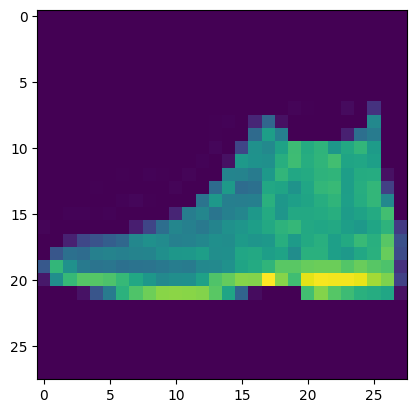

In [ ]:
plt.imshow(X[0].cpu().squeeze())
plt.show()

## 11. Visualize a Sample Image

This cell visualizes the first image from a batch of test data. The `squeeze()` method removes the channel dimension if it's 1, which is often needed for `matplotlib.pyplot.imshow` to display grayscale images correctly. This allows us to visually inspect what the model is predicting.

## Conclusion

This notebook provides a complete workflow for training a simple neural network on the FashionMNIST dataset using PyTorch, from data loading to model saving and inference. It demonstrates fundamental concepts of deep learning with PyTorch.